# JAX-Accelerated Kolmogorov-Arnold Network (KAN) for Symbolic Regression

This notebook demonstrates training a **Kolmogorov-Arnold Network (KAN)** in pure JAX on the **Relativistic Time Dilation** equation ($I.15.3t$) from the AI Feynman database:

$$t' = \frac{t}{\sqrt{1 - \frac{v^2}{c^2}}}$$

### How KANs Differ from MLPs
- **Multi-Layer Perceptrons (MLPs)**: Have linear weights on edges and fixed activation functions (like ReLU or SiLU) on nodes: $y = \sigma(w \cdot x)$.
- **Kolmogorov-Arnold Networks (KANs)**: Have learnable activation functions (parameterized as **B-splines**) on the edges and sum operations on the nodes. KANs can learn extremely complex, smooth univariate relationships per-edge.

We will use a highly optimized implementation in JAX, using `jnp.einsum` for tensor contraction and `@jax.jit` for compiling the training updates.

In [1]:
import sys
import os
sys.path.append(os.path.abspath("../../"))

import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
import time
from eigenflow.datasets import FeynmanDatasetGenerator

# Set up JAX keys
key = jax.random.PRNGKey(42)
dataset_key, init_key = jax.random.split(key)

# 1. Initialize dataset generator for Relativistic Time Dilation
generator = FeynmanDatasetGenerator("I.15.3t")

# 2. Generate 20,000 samples scaled to [-1, 1] with 1% noise
# Note: KAN splines require inputs strictly scaled within grid boundaries (e.g. [-1, 1])
X, y, metadata = generator.generate(
    key=dataset_key,
    num_samples=20000,
    noise_level=0.01,
    noise_type="gaussian",
    input_scaling="minmax_11",
    target_scaling="raw"
)

print(f"Generated {X.shape[0]} samples with {X.shape[1]} input variables.")
print(f"Formula: {metadata['formula']}")
print(f"Input ranges: {X.min()} to {X.max()}")

Generated 20000 samples with 3 input variables.
Formula: t / sqrt(1 - v^2/c^2)
Input ranges: -0.9999778270721436 to 0.9999777674674988


In [2]:
from functools import partial

# --- 1. JAX B-Spline Basis Functions (Cox-de Boor Recursion) ---

@partial(jax.jit, static_argnums=(2,))
def compute_b_splines(x, grid, spline_order):
    """
    Computes B-spline basis functions for input x over a specified knot grid.
    """
    x = jnp.expand_dims(x, axis=-1)  # Shape: (batch_size, in_features, 1)
    grid = jnp.expand_dims(grid, axis=0)  # Shape: (1, in_features, grid_size + 2 * spline_order + 1)
    
    # Base case: 0-degree basis (piecewise constant indicators)
    bases = ((x >= grid[:, :, :-1]) & (x < grid[:, :, 1:])).astype(x.dtype)
    
    # Higher-degree basis via recurrence relation
    for k in range(1, spline_order + 1):
        denom1 = grid[:, :, k:-1] - grid[:, :, :-(k + 1)]
        denom1 = jnp.where(denom1 == 0.0, 1.0, denom1)  # Avoid division by zero
        
        denom2 = grid[:, :, k + 1:] - grid[:, :, 1:-k]
        denom2 = jnp.where(denom2 == 0.0, 1.0, denom2)
        
        term1 = (x - grid[:, :, :-(k + 1)]) / denom1 * bases[:, :, :-1]
        term2 = (grid[:, :, k + 1:] - x) / denom2 * bases[:, :, 1:]
        bases = term1 + term2
        
    return bases


In [3]:

# --- 2. KAN Layer & Parameter Initialization ---

def init_kan_params(key, in_features, out_features, grid_size, spline_order, grid_min=-1.0, grid_max=1.0):
    k1, k2 = jax.random.split(key)
    
    # Base weights: shape (in_features, out_features) - used for the residual connection
    limit = jnp.sqrt(6.0 / (in_features + out_features))
    w_base = jax.random.uniform(k1, shape=(in_features, out_features), minval=-limit, maxval=limit)
    
    # Spline weights: shape (in_features, out_features, grid_size + spline_order)
    w_spline = jax.random.normal(k2, shape=(in_features, out_features, grid_size + spline_order)) * 0.1
    
    # Grid: shape (in_features, grid_size + 2 * spline_order + 1)
    h = (grid_max - grid_min) / grid_size
    grid = jnp.linspace(
        grid_min - spline_order * h,
        grid_max + spline_order * h,
        grid_size + 2 * spline_order + 1
    )
    grid = jnp.tile(grid, (in_features, 1))
    
    return (w_base, w_spline), grid

def init_network_params(key, layer_sizes, grid_size, spline_order, grid_min=-1.0, grid_max=1.0):
    keys = jax.random.split(key, len(layer_sizes) - 1)
    network_params = []
    network_grids = []
    for i in range(len(layer_sizes) - 1):
        in_feat = layer_sizes[i]
        out_feat = layer_sizes[i+1]
        params, grid = init_kan_params(keys[i], in_feat, out_feat, grid_size, spline_order, grid_min, grid_max)
        network_params.append(params)
        network_grids.append(grid)
    return network_params, network_grids

def kan_layer(x, params, grid, spline_order):
    w_base, w_spline = params
    # 1. Base residual: SiLU activation + linear weights
    base_out = jnp.matmul(jax.nn.silu(x), w_base)
    
    # 2. Spline evaluation: B-splines contracted with spline weights using einsum
    # bases shape: (batch_size, in_features, grid_size + spline_order)
    # w_spline shape: (in_features, out_features, grid_size + spline_order)
    bases = compute_b_splines(x, grid, spline_order)
    spline_out = jnp.einsum('bij,ioj->bo', bases, w_spline)
    
    return base_out + spline_out


In [4]:
# --- 3. Multi-Layer KAN & Training Helpers ---
@partial(jax.jit, static_argnums=(3,))
def kan_network(x, network_params, network_grids, spline_order):
    h = x
    for params, grid in zip(network_params, network_grids):
        h = kan_layer(h, params, grid, spline_order)
    return h

def loss_fn(params_list, network_grids, X_data, y_data, spline_order):
    preds = kan_network(X_data, params_list, network_grids, spline_order)
    return jnp.mean((jnp.squeeze(preds) - y_data) ** 2)

@partial(jax.jit, static_argnums=(5,))
def train_step(params_list, network_grids, opt_state, X_data, y_data, spline_order):
    loss_val, grads = jax.value_and_grad(loss_fn, argnums=0)(
        params_list, network_grids, X_data, y_data, spline_order
    )
    updates, opt_state = optimizer.update(grads, opt_state, params_list)
    params_list = optax.apply_updates(params_list, updates)
    return params_list, opt_state, loss_val


In [5]:
# --- 4. Setup and Training --- 
# KAN Hyperparameters
layer_sizes = [3, 16, 16, 1]  # Much smaller width than MLP due to KAN's edge representation power
grid_size = 5                 # Number of intervals in spline grid
spline_order = 3              # Cubic B-splines

network_params, network_grids = init_network_params(
    init_key, layer_sizes, grid_size, spline_order, grid_min=-1.0, grid_max=1.0
)

# Optimizer setup
lr = 5e-3
optimizer = optax.adam(lr)
opt_state = optimizer.init(network_params)

# Split train/test sets
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Pre-compile update step with dummy data
print("Compiling JAX KAN...")
_, _, _ = train_step(
    network_params, network_grids, opt_state, X_train[:10], y_train[:10], spline_order
)

# Train loop
epochs = 3000
losses = []
test_losses = []

print("Starting training...")
start_time = time.time()

for epoch in range(epochs):
    network_params, opt_state, loss = train_step(
        network_params, network_grids, opt_state, X_train, y_train, spline_order
    )
    losses.append(loss)
    
    if epoch % 500 == 0 or epoch == epochs - 1:
        test_loss = loss_fn(network_params, network_grids, X_test, y_test, spline_order)
        test_losses.append((epoch, float(test_loss)))
        print(f"Epoch {epoch:4d} | Train Loss: {loss:.6f} | Test Loss: {test_loss:.6f}")

end_time = time.time()
total_time = end_time - start_time
print(f"\nTraining completed in: {total_time:.4f} seconds!")
print(f"Time per epoch: {total_time/epochs*1000:.4f} milliseconds.")


Compiling JAX KAN...
Starting training...
Epoch    0 | Train Loss: 46.897511 | Test Loss: 40.627979
Epoch  500 | Train Loss: 0.002088 | Test Loss: 0.002045
Epoch 1000 | Train Loss: 0.001256 | Test Loss: 0.001266
Epoch 1500 | Train Loss: 0.001053 | Test Loss: 0.001073
Epoch 2000 | Train Loss: 0.000964 | Test Loss: 0.000987
Epoch 2500 | Train Loss: 0.000918 | Test Loss: 0.000943
Epoch 2999 | Train Loss: 0.000891 | Test Loss: 0.000917

Training completed in: 29.6718 seconds!
Time per epoch: 9.8906 milliseconds.


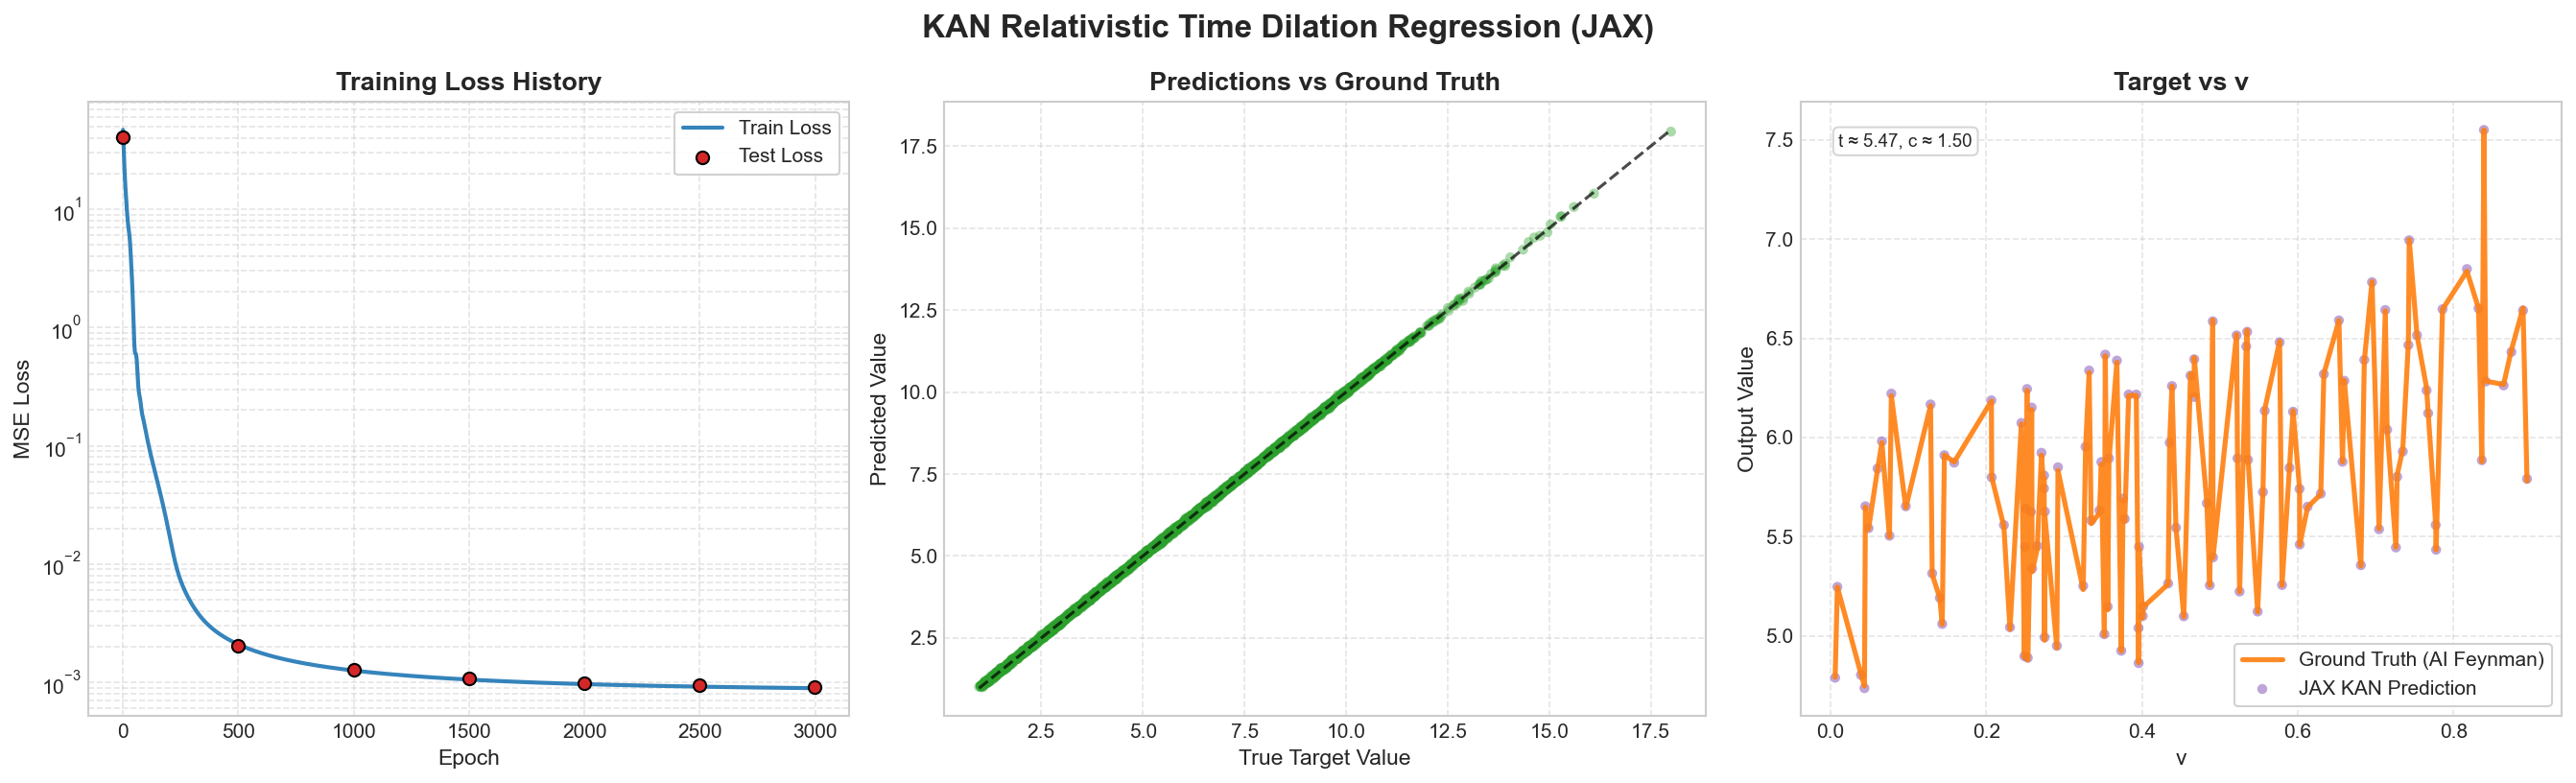

In [6]:
# --- 5. Visualizing KAN Predictions ---

preds_test = kan_network(X_test, network_params, network_grids, spline_order)
preds_test = jnp.squeeze(preds_test)
raw_test_inputs = metadata["X_raw"][split:]
raw_test_targets = metadata["y_raw"][split:]

from eigenflow.utils import plot_regression_results

plot_regression_results(
    losses=losses,
    y_true=y_test,
    y_pred=preds_test,
    test_losses=test_losses,
    X_raw=raw_test_inputs,
    y_raw=raw_test_targets,
    variables=metadata["variables"],
    slice_feature_idx=1,
    model_label="JAX KAN Prediction",
    title="KAN Relativistic Time Dilation Regression (JAX)"
)